In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *
import pandas as pd
from joblib import Parallel, delayed

In [ ]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

ids = read_ids('./samples_ids/dp_candidates_ids.txt')

SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit, load_targetID=ids)


In [3]:
# SPECTRA.shrink_dataset(10)
SPECTRA.stack_data()
SPECTRA.mask_bad()

In [4]:
FIT     = FitSpectrum()
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)
SPECTRA = FIT.label_emission_lines(SPECTRA, 3)
print(SPECTRA.n_spectra)


26305


In [ ]:
idx = np.random.choice(SPECTRA.n_spectra, size=1, replace=False)[0]
id = SPECTRA.targetID[idx]
id = 39627757704971300
idx = SPECTRA.id2index(id)
display(SPECTRA.df[SPECTRA.df['TARGETID']==id])

,TARGETID,RA,DEC,SPECTYPE,FLUX_G,FLUX_R,FLUX_Z,LOGM,LOGSFR,z_pipe,z,OII,Hbeta,OIII,Halpha,NII,SII
25377,39627818694346513,224.581447,1.326845,GALAXY,11.662946,23.329287,41.494244,10.057572,1.314371,0.214033,0.214033,True,True,True,True,True,True


39627818694346513
Saved ./images/39627818694346513_image.jpg


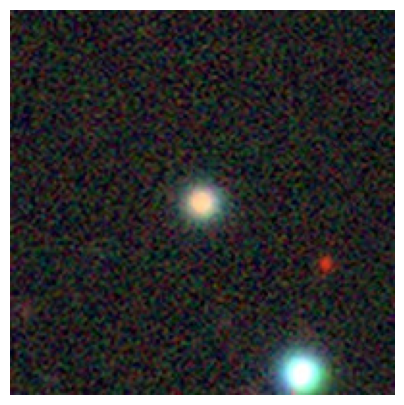

https://www.legacysurvey.org/viewer?ra=224.58144687455302&dec=1.3268452208901325&layer=ls-dr10-grz&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627818694346513


In [41]:
print(SPECTRA.targetID[idx])
print(image_link(SPECTRA.df['RA'].to_numpy()[idx], SPECTRA.df['DEC'].to_numpy()[idx], plot=True, save_image=True, fname=f"./images/{SPECTRA.targetID[idx]}_image.jpg"))
print(spectrum_link(SPECTRA.targetID[idx]))

In [42]:
params_1comp_free, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=False, w_dz=False)

lams = np.split(combine_lam, slice_indices)

combine_model_lam = np.concatenate([
                model_vel(lams[i], gaussian_parms=params_1comp_free['gaussian_params'][i]) 
                for i in range(len(lams))
            ])
model_lam_1comp_free = combine_model_lam

combine_flux_1comp_free = combine_flux

chisq_1comp_free = np.sum(((combine_flux_1comp_free - model_lam_1comp_free)/combine_sigma)**2)



dof_1comp_free = len(combine_lam) - (1+n_lines_fit)
# 1: sigma_1

In [43]:
params_2comp_free, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=True, w_dz=False)
print(f'dz: {params_2comp_free["dz"]}')

combine_flux_2comp_free = combine_flux

lams = np.split(combine_lam, slice_indices)

combine_model_lam = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['gaussian_params'][i]) for i in range(len(lams))
])
model_lam_2comp_free = combine_model_lam

left_comp_dz_free = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['left_comp'][i]) for i in range(len(lams))
])
right_comp_dz_free = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['right_comp'][i]) for i in range(len(lams))
])
model_lam_2comp_free = left_comp_dz_free + right_comp_dz_free

chisq_2comp_free = np.sum(((combine_flux_2comp_free - model_lam_2comp_free)/combine_sigma)**2)
residual_2comp = combine_flux_2comp_free - model_lam_2comp_free
# print(f'Chi-sq dz free: {chisq_dz_free}')


dof_2comp_free = len(combine_lam) - (4+n_lines_fit*2)
# 4: sigma_1, sigma_2, dz_r, dz_l

dz: 0


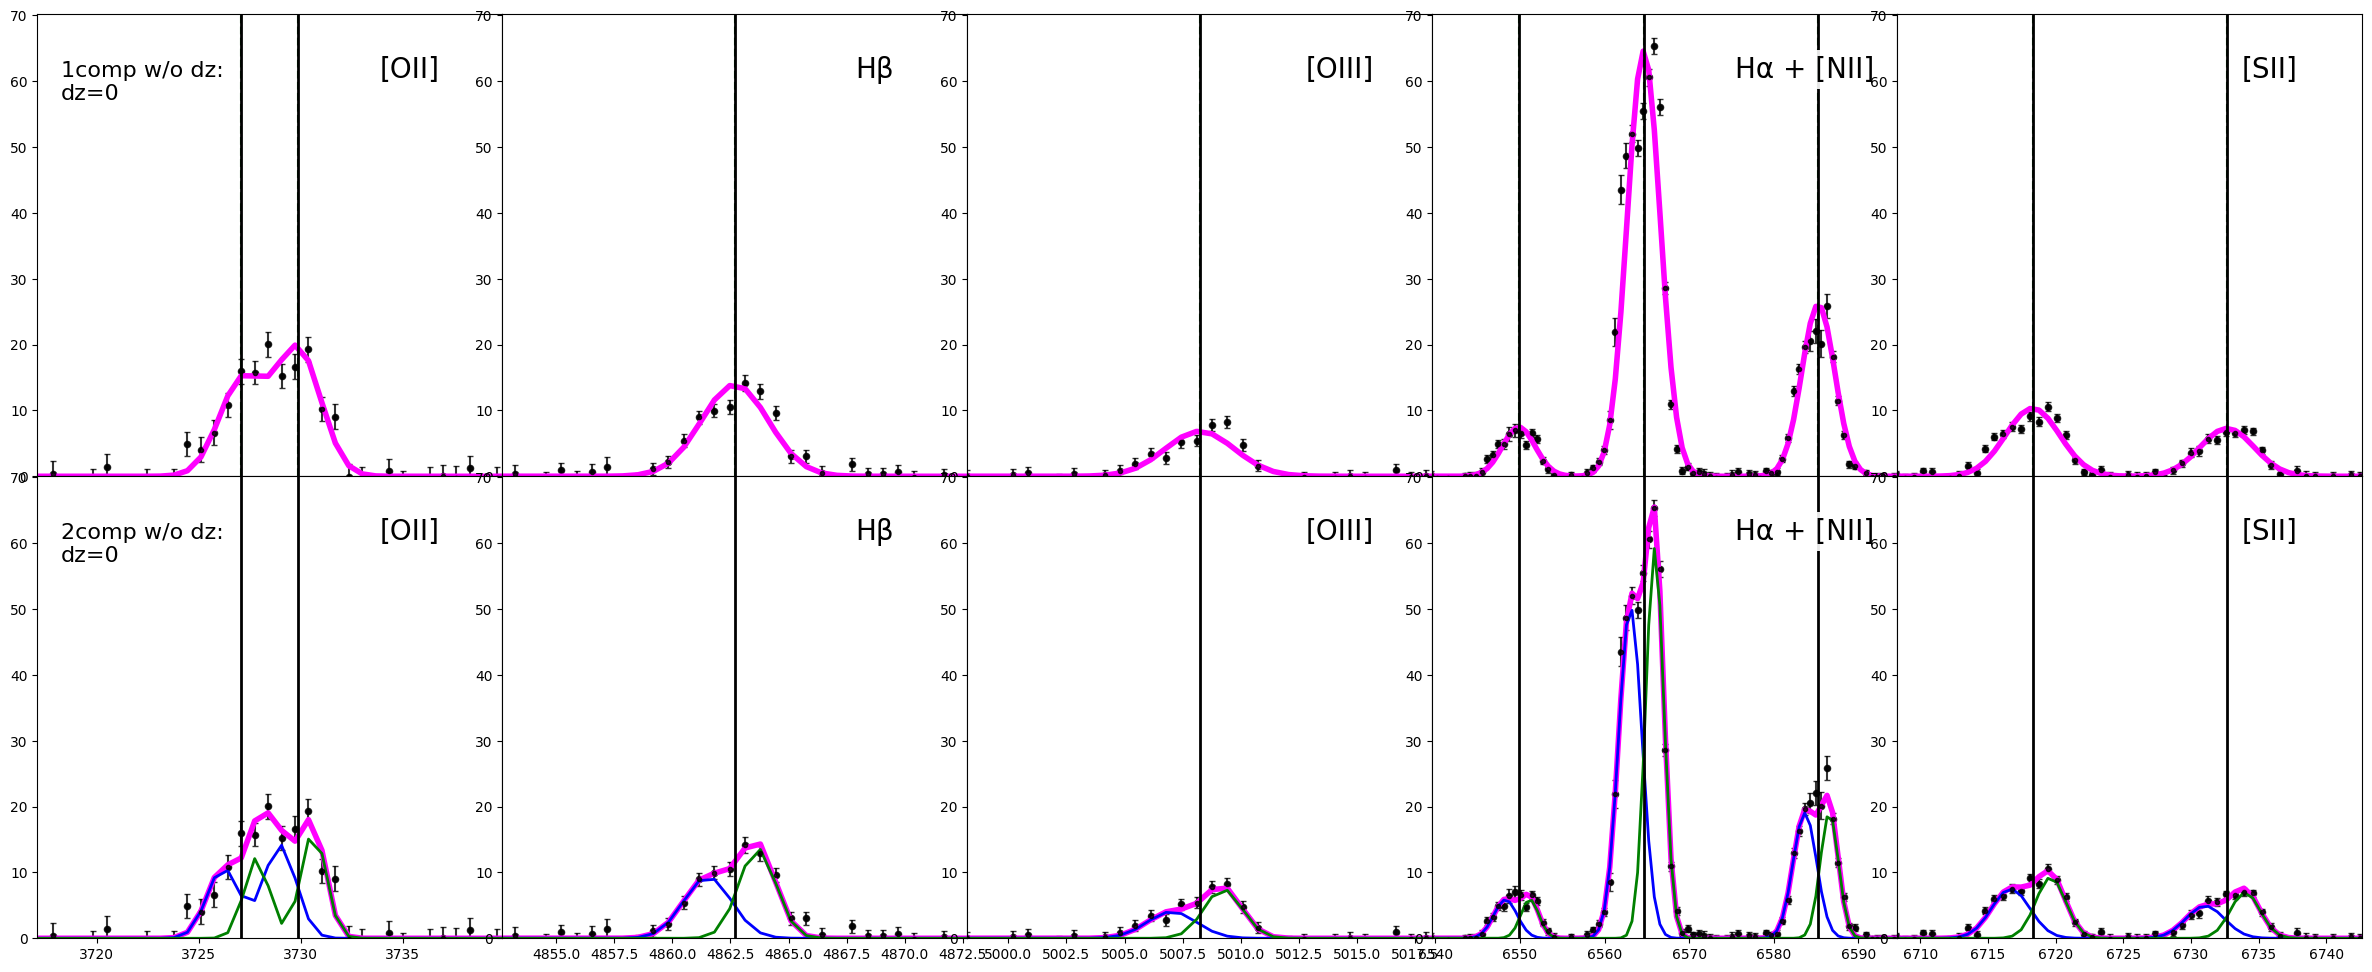

In [44]:
fig, axes = plt.subplots(2, 5, figsize=(30, 12))
plt.subplots_adjust(hspace=0.0, wspace=0.00)

observed_lam = SPECTRA.data_stack[idx, :, 0]
observed_flux = SPECTRA.data_stack[idx, :, 1]
observed_sigma = np.sqrt(np.divide(1, np.abs(SPECTRA.data_stack[idx, :, 2]), where=SPECTRA.data_stack[idx, :, 2]!=0, out=np.zeros_like(SPECTRA.data_stack[idx, :, 2], dtype=float)))

# 1 comp free
ax = axes[0, :]
ax[0].text(0.05, 0.9, f'1comp w/o dz: \ndz=0', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].errorbar(combine_lam, combine_flux_1comp_free, yerr=combine_sigma, label='Observed', fmt='.', color='k', alpha=0.8, capsize=2)
    ax[i].scatter(combine_lam, combine_flux_1comp_free, label='Observed', color='k', alpha=0.8, s=20)
    # ax[i].step(combine_lam, combine_flux_1comp_free, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_lam_1comp_free, label='Fitted model_vel', color='magenta', linewidth=4)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0, color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)


# 2 comp free
ax = axes[1, :]
ax[0].text(0.05, 0.9, f'2comp w/o dz: \ndz=0', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].errorbar(combine_lam, combine_flux_2comp_free, yerr=combine_sigma, label='Observed', fmt='.', color='k', alpha=0.8, capsize=2)
    ax[i].scatter(combine_lam, combine_flux_2comp_free, label='Observed', color='k', alpha=0.8, s=20)
    # ax[i].step(combine_lam, combine_flux_2comp_free, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_lam_2comp_free, label='Fitted model_vel', color='magenta', linewidth=4)
    ax[i].plot(combine_lam, left_comp_dz_free, label='Left Component', color='blue', linestyle='-', linewidth=2)
    ax[i].plot(combine_lam, right_comp_dz_free, label='Right Component', color='green', linestyle='-', linewidth=2)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_2comp_free['dv'][0]), color='darkgreen', linestyle=':', alpha=.5, linewidth=1.5)
        ax[i].axvline(l0*(1+params_2comp_free['dv'][1]), color='darkblue', linestyle=':', alpha=.5, linewidth=1.5)
        # ax[i].axvline(l0*(1+dz_centroid), color='gray', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)
        
        
for i in range(2):
    ax = axes[i, :]
    ax[0].text(0.80, 0.85, '[OII]', transform=ax[0].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[0].set_xlim([OII_rest[0]-10, OII_rest[1]+10])  
    # ax[0].set_ylim(bottom=-0., top=np.max(observed_flux[(observed_lam>=OII_rest[0]-10) & (observed_lam<=OII_rest[1]+10)])*1.2)
    ax[0].set_ylim(bottom=-0.)

    ax[1].text(0.80, 0.85, 'Hβ', transform=ax[1].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[1].set_xlim([Hbeta_rest[0]-10, Hbeta_rest[0]+10])
    # ax[1].set_ylim(bottom=-0., top=np.max(observed_flux[(observed_lam>=Hbeta_rest[0]-10) & (observed_lam<=Hbeta_rest[0]+10)])*1.2)
    ax[1].set_ylim(bottom=-0.)
    
    ax[2].text(0.80, 0.85, '[OIII]', transform=ax[2].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[2].set_xlim([OIII_rest[1]-10, OIII_rest[1]+10])
    # ax[2].set_ylim(bottom=-0., top=np.max(observed_flux[(observed_lam>=OIII_rest[0]-10) & (observed_lam<=OIII_rest[1]+10)])*1.2)
    ax[2].set_ylim(bottom=-0.)
    
    ax[3].text(0.80, 0.85, 'Hα + [NII]', transform=ax[3].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[3].set_xlim([Halpha_rest[0]-25, Halpha_rest[0]+30])
    # ax[3].set_ylim(bottom=-0, top=np.max(observed_flux[(observed_lam>=Halpha_rest[0]-25) & (observed_lam<=Halpha_rest[0]+30)])*1.2)
    ax[3].set_ylim(bottom=-0)
    
    ax[4].text(0.80, 0.85, '[SII]', transform=ax[4].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[4].set_xlim([SII_rest[0]-10, SII_rest[1]+10])
    # ax[4].set_ylim(bottom=-0., top=np.max(observed_flux[(observed_lam>=SII_rest[0]-10) & (observed_lam<=SII_rest[1]+10)])*1.2)
    ax[4].set_ylim(bottom=-0.)

plt.savefig(f'./figures/Jan2/{id}_spectrum.png')
plt.show()
